Qui facciamo un po' di esperimenti in cui alleniamo degli alberi (cioè $\mathcal H_d$ è il set di alberi binari con depth $d$) con una counting loss ad imparare a predire 
\begin{equation}
    y = \mathrm{sign}\left(f^*(x) + \sigma \varepsilon\right)
\end{equation}
where $f^*$ is a sine function that crosses the x axes $m$ times; $\varepsilon\sim \mathcal N(0,1)$ and the total noise has variance controlled by $\sigma$; the support of the data $\mathcal X$ is a discretization of the interval $[0,10]$ in $N$ points, the training data is sampled with a measure $p_{\mathcal X}$ and has size $n$.  

We want to observe how the shape of the curve $(d, R(f))$ (where $f$ is the tree and $R(f)$ is the test error) changes with
- $\sigma$
- $m$
- $n$
- $N$
- $p_{\mathcal X}$


#### how to use


questo codice funziona che per ogni fader che voglio tunare faccio:
- copio il codice della prima cella sotto a `Noise`
- metto sotto a  ```# fader to be tuned``` il nome del cursore di quel momento e la lista dei valori che gli voglio dare
- poi cambio tutte le occurrences di ```my_noise_std(s)``` con il nome del mio parametro preceduto da ```my_```, altrimenti poi resta come l'ultimo della lista per tutto il resto del codice.

è semplice! ricorda che di default servono 6 valori del tuo cursore, se li vuoi cambiare devi cambiare le misure dei plot nella primissima riga (```3, 2```). 

### Default setup + generic case

In [27]:
%run base.ipynb

mare


In [28]:
# MODEL
mymodel = DecisionTreeClassifier

# DEFAULT PARAMETERS
N = 10_000
m = 5
n = 50
noise_std = 2
px = "uniform" 

n_test = 200_000
T = 100

# DATA GENERATING FUNCTION
from functools import partial

gen_fun = partial(sine, num_crossings=m)

[checkpoint] bound: "naive" -> bound_naive, params: []


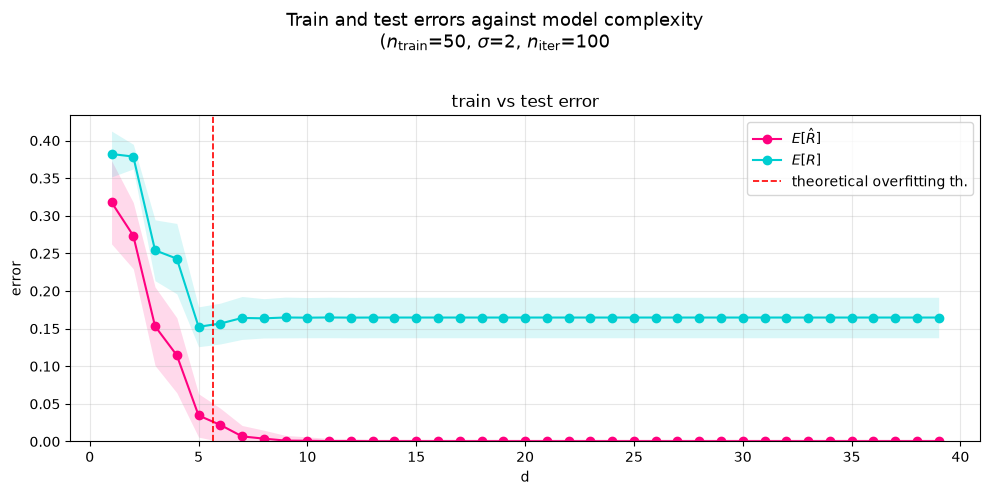

In [29]:
# build test set
x_test = sample_x(n_test, N)
y_test = sample_y(x = x_test, f = gen_fun, sigma = noise_std)


# build models and do plots
hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, predictions, x, y, x_grid = main_loop(
    x_test, y_test, n_train=n, sigma=noise_std, num_iter=T, model=mymodel, fun=gen_fun)
plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, n_train=n, 
      sigma=noise_std, num_iter=T, model=mymodel,
      two = False, three = False)

### Noise ($\sigma$)

[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []


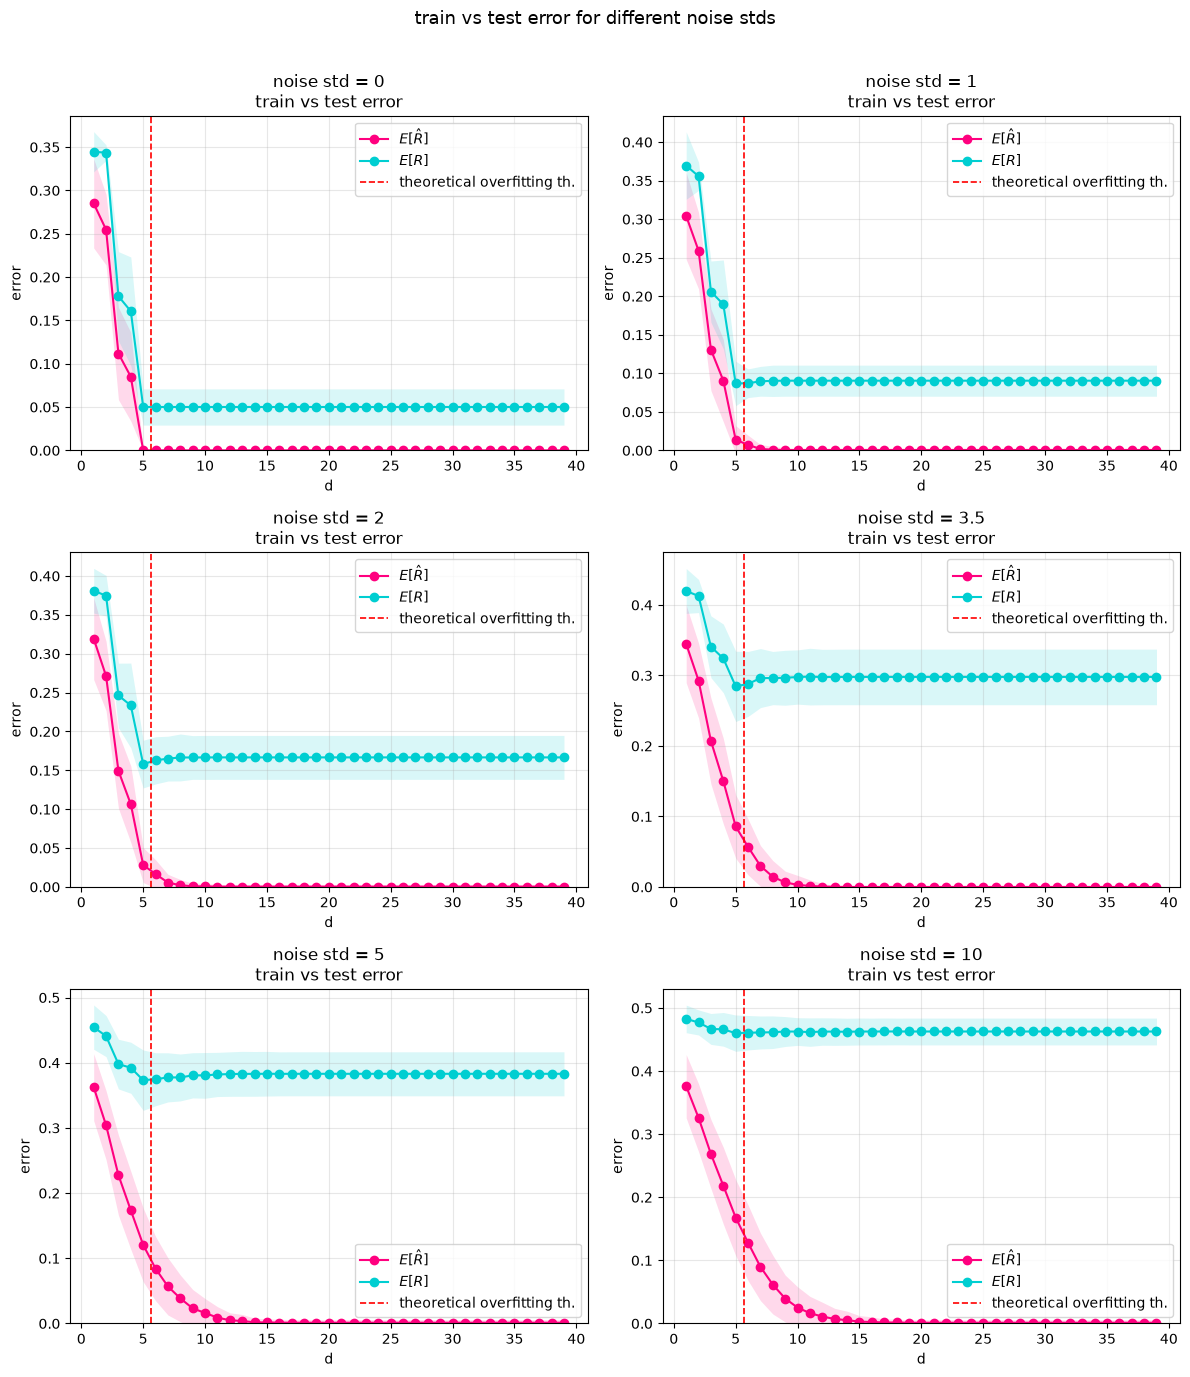

In [30]:
fig, axs = plt.subplots(3, 2, figsize=(12, 14))
fig.suptitle(r'train vs test error for different noise stds', fontsize=13)

# fader to be tuned
my_noise_stds = [0,1,2,3.5,5,10]

for ax, my_noise_std in zip(axs.flat, my_noise_stds):

    # build test set
    x_test = sample_x(n_test, N)
    y_test = sample_y(x=x_test, f=gen_fun, sigma=my_noise_std)

    # build models and do plots 
    hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, *_ = main_loop(
        x_test, y_test, n_train=n, sigma=my_noise_std, num_iter=T, model=mymodel, fun=gen_fun)
    plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, 
          n_train=n, sigma=my_noise_std, num_iter=T, model=mymodel, 
        two=False, three=False, axes=[ax])
    ax.set_title(f'noise std = {my_noise_std}\ntrain vs test error')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Complessità funzione sotto ($m$)

[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []


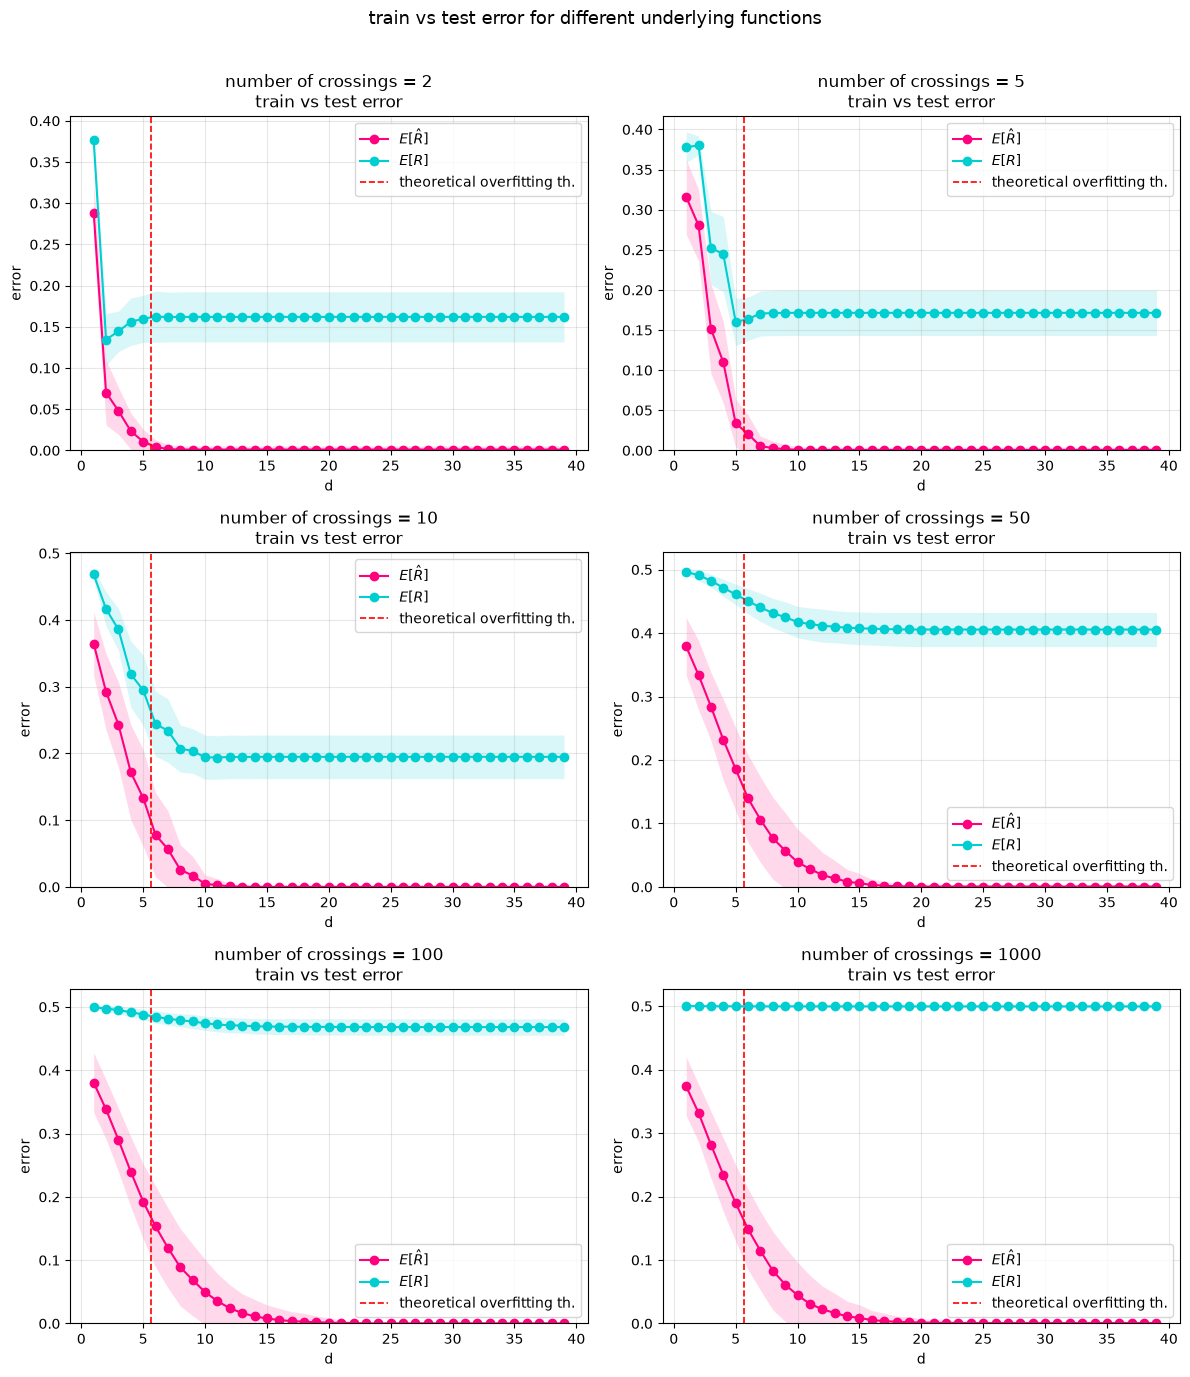

In [31]:
fig, axs = plt.subplots(3, 2, figsize=(12, 14))
fig.suptitle(r'train vs test error for different underlying functions', fontsize=13)

# fader to be tuned
my_ms = [2, 5, 10, 50, 100, 1000]

for ax, my_m in zip(axs.flat, my_ms):
    my_gen_fun = partial(sine, num_crossings=my_m)

    # build test set
    x_test = sample_x(n_test, N)
    y_test = sample_y(x=x_test, f=my_gen_fun, sigma=noise_std)

    # build models and do plots 
    hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, *_ = main_loop(
        x_test, y_test, n_train=n, sigma=noise_std, num_iter=T, model=mymodel, fun=my_gen_fun)
    plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, 
          n_train=n, sigma=noise_std, num_iter=T, model=mymodel, 
        two=False, three=False, axes=[ax])
    ax.set_title(f'number of crossings = {my_m}\ntrain vs test error')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Training size ($n$)

[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []


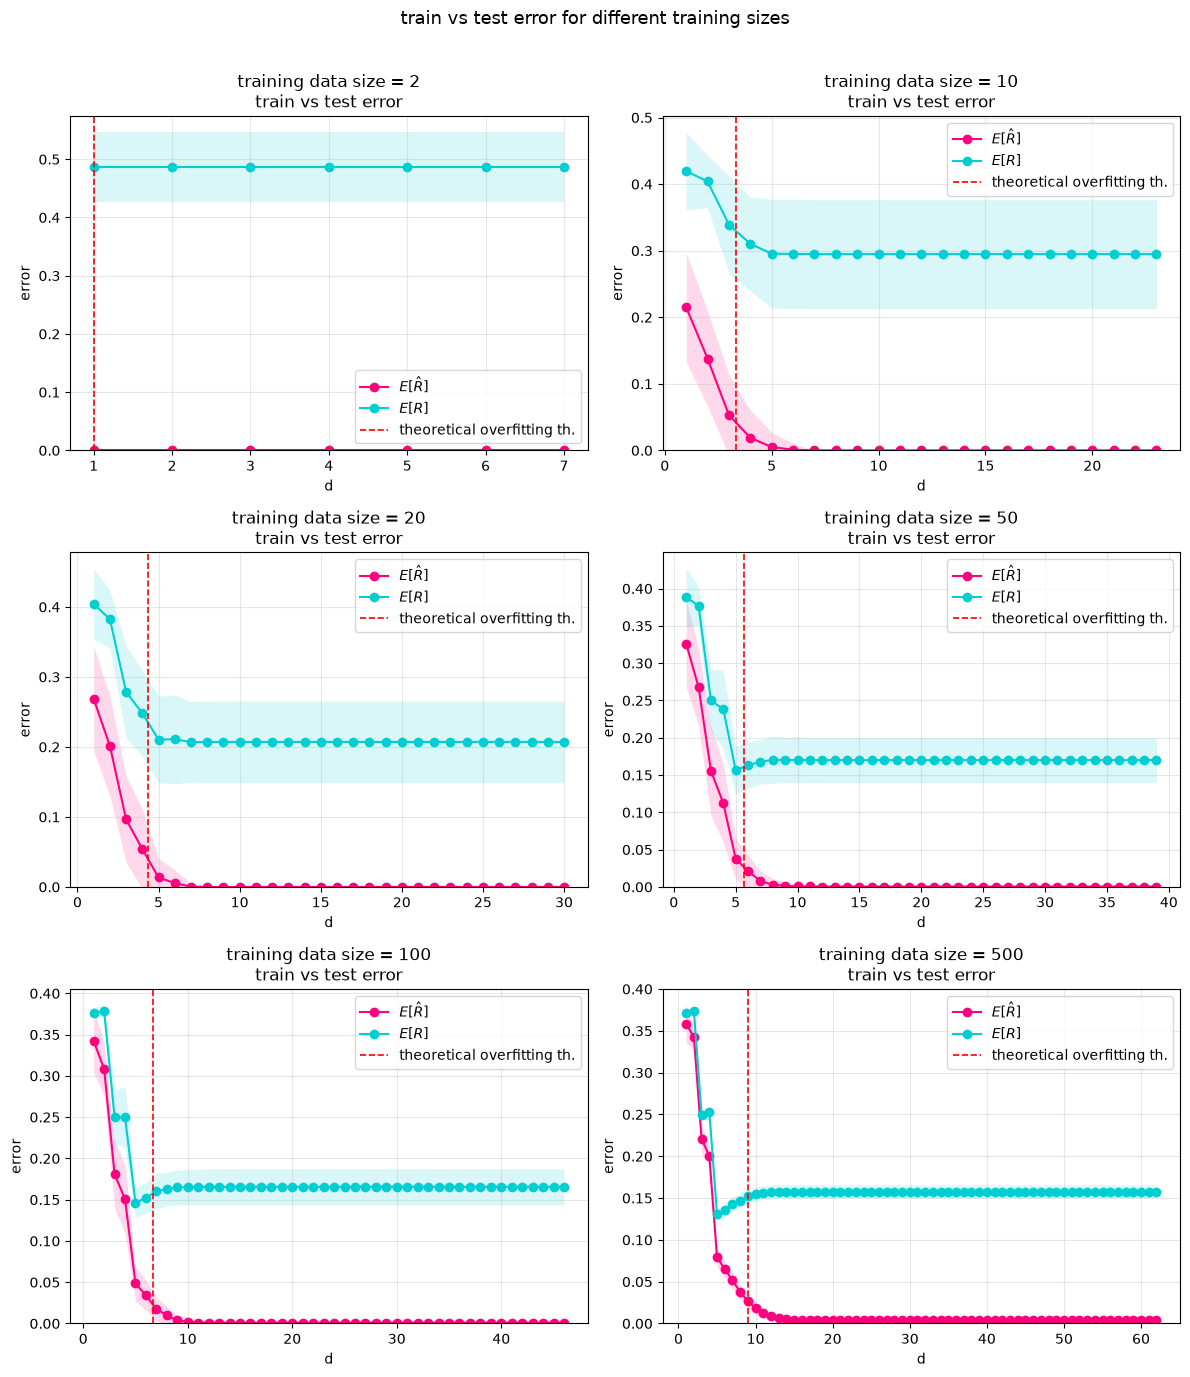

In [32]:
fig, axs = plt.subplots(3, 2, figsize=(12, 14))
fig.suptitle(r'train vs test error for different training sizes', fontsize=13)

# fader to be tuned
my_ns = [2, 10, 20, 50, 100, 500]

for ax, my_n in zip(axs.flat, my_ns):

    # build test set
    x_test = sample_x(n_test, N)
    y_test = sample_y(x=x_test, f=gen_fun, sigma=noise_std)

    # build models and do plots 
    hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, *_ = main_loop(
        x_test, y_test, n_train=my_n, sigma=noise_std, num_iter=T, model=mymodel, fun=gen_fun)
    plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, 
          n_train=my_n, sigma=noise_std, num_iter=T, model=mymodel, 
        two=False, three=False, axes=[ax])
    ax.set_title(f'training data size = {my_n}\ntrain vs test error')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Support size ($N$)

[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []


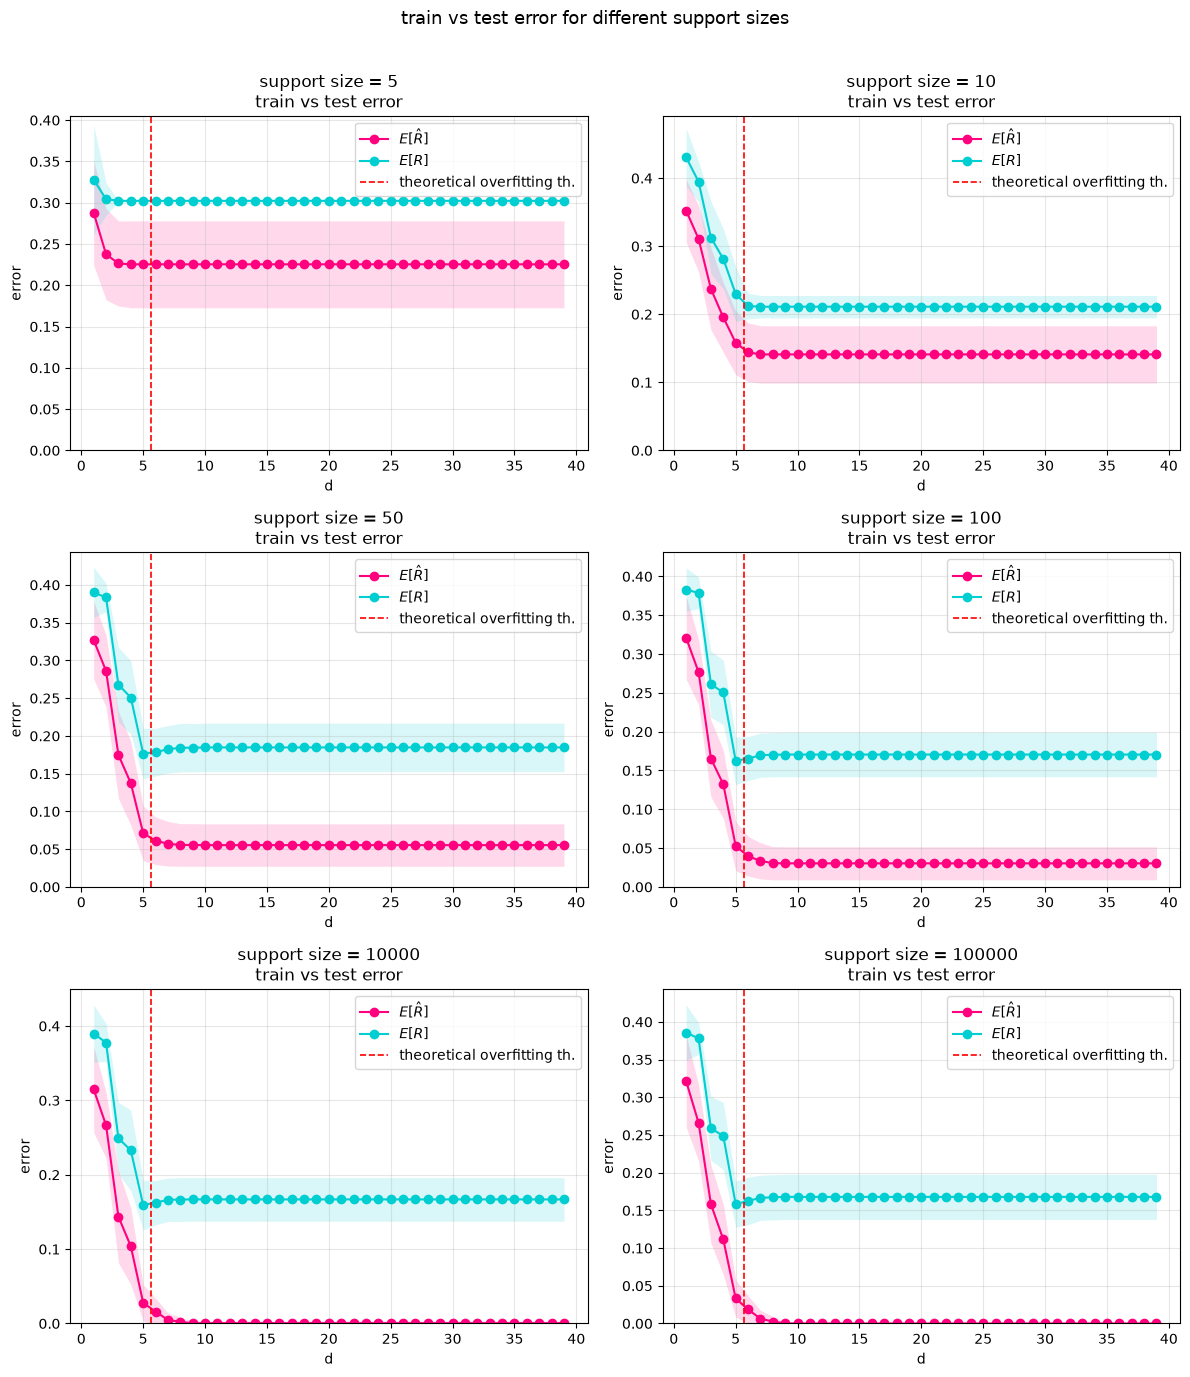

In [33]:
fig, axs = plt.subplots(3, 2, figsize=(12, 14))
fig.suptitle(r'train vs test error for different support sizes', fontsize=13)

# fader to be tuned
my_Ns = [5, 10, 50, 100, 10_000, 100_000]

for ax, my_N in zip(axs.flat, my_Ns):

    # build test set
    x_test = sample_x(n_test, my_N)
    y_test = sample_y(x=x_test, f=gen_fun, sigma=noise_std)

    # build models and do plots 
    hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, *_ = main_loop(
        x_test, y_test, n_train=n, sigma=noise_std, num_iter=T, N = my_N, model=mymodel, fun=gen_fun)
    plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, 
          n_train=n, sigma=noise_std, num_iter=T, model=mymodel, 
        two=False, three=False, axes=[ax])
    ax.set_title(f'support size = {my_N}\ntrain vs test error')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Measure over the support ($p_{\mathcal X}$)

[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []
[checkpoint] bound: "naive" -> bound_naive, params: []


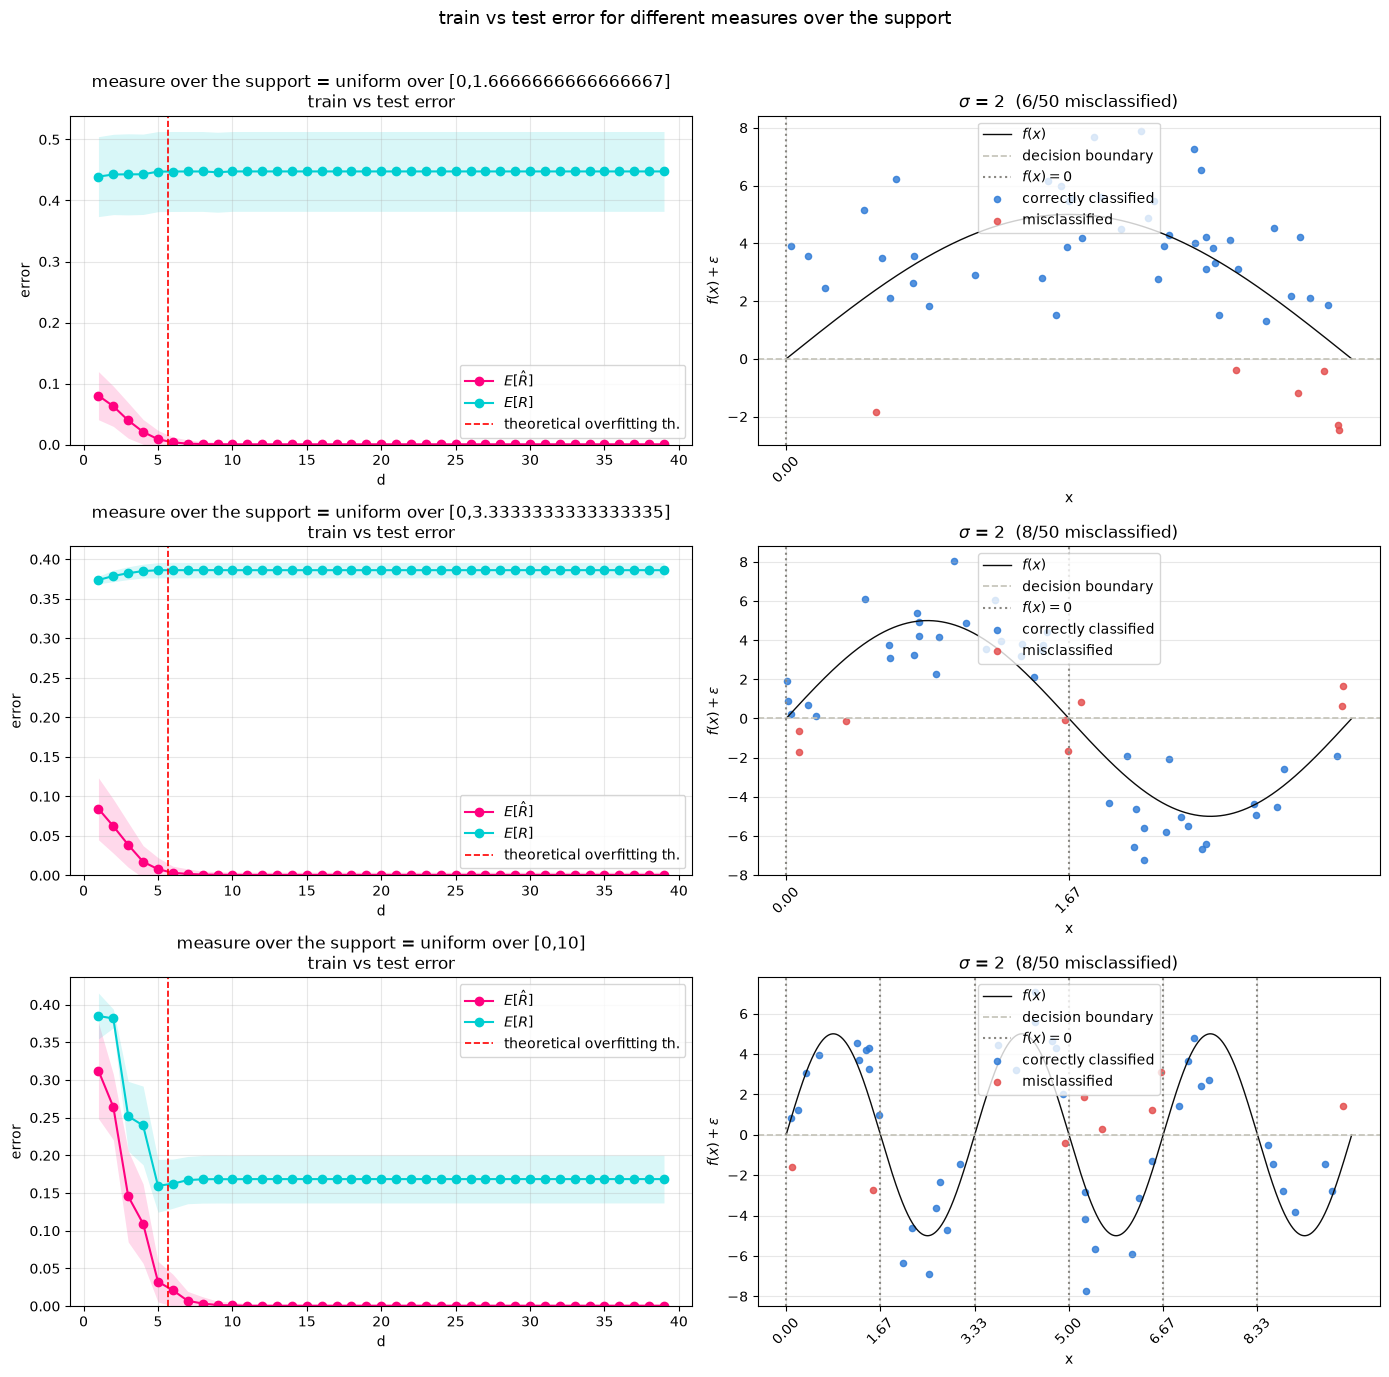

In [34]:
fig, axs = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle(r'train vs test error for different measures over the support', fontsize=13)

# fader to be tuned
my_pxs = [5/3, 10/3, 10] 
# definisco le nuove misure come una uniform su intervalli diversi: 10 -> tutto, 5/3 -> mezzo periodo (f*(x) solo positiva), 10/3 -> primo periodo) e samplo solo il training su questi, mentre il test sempre su tutto [0, 10]

for (ax, ax_data), my_px in zip(axs, my_pxs):
    
    # build test set
    x_test = sample_x(n_test, N, u = 10)
    y_test = sample_y(x=x_test, f=gen_fun, sigma=noise_std)

    # build models and do plots 
    hat_Rs, Rs, gaps, std_hat_Rs, std_Rs, std_gaps, *_ = main_loop(
        x_test, y_test, n_train=n, sigma=noise_std, num_iter=T, model=mymodel, fun=gen_fun,
        u = my_px)
    plots(hat_Rs, Rs, gaps, std_hat_Rs=std_hat_Rs, std_Rs=std_Rs, std_gaps=std_gaps, 
          n_train=n, sigma=noise_std, num_iter=T, model=mymodel, 
        two=False, three=False, axes=[ax])
    ax.set_title(f'measure over the support = uniform over [0,{my_px}]\ntrain vs test error')

    explore_data(fun=gen_fun, n_train=n, supp_size=N, u=my_px, sigmas=[noise_std], axes=[ax_data])

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


